# ¡Hola Sebastian! <a class="tocSkip"></a>

Mi nombre es Oscar Flores y tengo el gusto de revisar tu proyecto. Si tienes algún comentario que quieras agregar en tus respuestas te puedes referir a mi como Oscar, no hay problema que me trates de tú.

Si veo un error en la primera revisión solamente lo señalaré y dejaré que tú encuentres de qué se trata y cómo arreglarlo. Debo prepararte para que te desempeñes como especialista en Data, en un trabajo real, el responsable a cargo tuyo hará lo mismo. Si aún tienes dificultades para resolver esta tarea, te daré indicaciones más precisas en una siguiente iteración.

Te dejaré mis comentarios más abajo - **por favor, no los muevas, modifiques o borres**

Comenzaré mis comentarios con un resumen de los puntos que están bien, aquellos que debes corregir y aquellos que puedes mejorar. Luego deberás revisar todo el notebook para leer mis comentarios, los cuales estarán en rectángulos de color verde, amarillo o rojo como siguen:

<div class='alert alert-block alert-success'>
<b>Comentario de Reviewer</b> <a class='tocSkip'></a>

Muy bien! Toda la respuesta fue lograda satisfactoriamente.
</div>

<div class='alert alert-block alert-warning'>
<b>Comentario de Reviewer</b> <a class='tocSkip'></a>

Existen detalles a mejorar. Existen recomendaciones.
</div>

<div class='alert alert-block alert-danger'>

<b>Comentario de Reviewer</b> <a class='tocSkip'></a>

Se necesitan correcciones en el bloque. El trabajo no puede ser aceptado con comentarios en rojo sin solucionar.
</div>

Cualquier comentario que quieras agregar entre iteraciones de revisión lo puedes hacer de la siguiente manera:

<div class='alert alert-block alert-info'>
<b>Respuesta estudiante.</b> <a class='tocSkip'></a>
</div>

Mucho éxito en el proyecto!

## Resumen de la revisión v1 <a class="tocSkip"></a>

<div class="alert alert-block alert-danger">
<b>Comentario de Revisor            </b> <a class="tocSkip"></a>

Hola Sebastian, ¿cómo estás? Espero que estés bien y avanzando con tranquilidad.

Felicitaciones por haber completado todos los ítems del notebook. El desarrollo está bien hecho y cumple con los requerimientos principales. Solo falta que agregues el análisis de juegos multiplataforma. Te dejé comentarios en rojo señalando qué se espera en este análisis comparativo.

Si necesitas ayuda o tienes alguna pregunta, puedes dejarla en azul, estaré encantado de responderla en la siguiente revisión.

¡Saludos!


</div>

## Resumen de la revisión v1 <a class="tocSkip"></a>

----

PROYECTO INTEGRADO
Analisis de datos de tienda online de videojuegos

In [1]:
import numpy as np
import pandas as pd
archivo_juegos = '/datasets/games.csv'
games_data = pd.read_csv(archivo_juegos)
print (games_data.head())

                       Name Platform  Year_of_Release         Genre  NA_sales  \
0                Wii Sports      Wii           2006.0        Sports     41.36   
1         Super Mario Bros.      NES           1985.0      Platform     29.08   
2            Mario Kart Wii      Wii           2008.0        Racing     15.68   
3         Wii Sports Resort      Wii           2009.0        Sports     15.61   
4  Pokemon Red/Pokemon Blue       GB           1996.0  Role-Playing     11.27   

   EU_sales  JP_sales  Other_sales  Critic_Score User_Score Rating  
0     28.96      3.77         8.45          76.0          8      E  
1      3.58      6.81         0.77           NaN        NaN    NaN  
2     12.76      3.79         3.29          82.0        8.3      E  
3     10.93      3.28         2.95          80.0          8      E  
4      8.89     10.22         1.00           NaN        NaN    NaN  


Abriry cargar los datos

PASO 2 Limpieza de datos

In [2]:
games_data.columns = games_data.columns.str.lower()
print(games_data.columns)

games_data.dropna(subset=['name', 'genre', 'year_of_release'], inplace=True)


Index(['name', 'platform', 'year_of_release', 'genre', 'na_sales', 'eu_sales',
       'jp_sales', 'other_sales', 'critic_score', 'user_score', 'rating'],
      dtype='object')


Conversion de datos en tipos necesarios

In [3]:
#Años de salida a entero
games_data['year_of_release'] = games_data['year_of_release'].astype('int')
#User:limpieza con dropna para ausentes y cambi a int
games_data.dropna(subset=['name', 'genre', 'year_of_release'], inplace=True)
games_data['year_of_release'] = games_data['year_of_release'].astype('int')
#manejo de tbd ya que marcaba value error
games_data['user_score'] = games_data['user_score'].replace('tbd', np.nan) 
games_data['user_score'] = pd.to_numeric(games_data['user_score'], errors='coerce')
#valores ausentes en ratin rellenados con unknown
games_data['rating'].fillna('Unknown', inplace=True)
print(games_data.head())

                       name platform  year_of_release         genre  na_sales  \
0                Wii Sports      Wii             2006        Sports     41.36   
1         Super Mario Bros.      NES             1985      Platform     29.08   
2            Mario Kart Wii      Wii             2008        Racing     15.68   
3         Wii Sports Resort      Wii             2009        Sports     15.61   
4  Pokemon Red/Pokemon Blue       GB             1996  Role-Playing     11.27   

   eu_sales  jp_sales  other_sales  critic_score  user_score   rating  
0     28.96      3.77         8.45          76.0         8.0        E  
1      3.58      6.81         0.77           NaN         NaN  Unknown  
2     12.76      3.79         3.29          82.0         8.3        E  
3     10.93      3.28         2.95          80.0         8.0        E  
4      8.89     10.22         1.00           NaN         NaN  Unknown  


Explicacion de como se manejo los valores ausentes.
Lo primero que se hizo fue eliminar las filas sin nombre, genero o año.
Se elimino NaN de year_realease ya que es necesario para convertirlo a int porque si no marca error
Se cambio TBD a Nan porque es necesario cambiar el tipode dato apra que podamos hacer analisis
Se cambio los NaN de rating a Unknown.
Los NaN DE user_score y critic_score se dejaron para que no altere nuestros calculos

<div class="alert alert-block alert-success">
<b>Comentario de Revisor          </b> <a class="tocSkip"></a>

Bien hecho con la gestión de los valores ausentes. En los casos donde hay demasiados en una columna, me parece bien dejar los nulos tal como están o reemplazarlos por algún valor identificable. En este caso, para critic_score y user_score, no hay data suficiente para hacer una imputación adecuada y en caso de rellenar con la media o mediana, se introduce un sesgo muy fuerte en la data, por lo que no es adecuado.



</div>

SUMA Y CREACION DE COLUMNA DE vENTAS TOTALES DE JUEGO EN TODAS LAS REGIONES

In [4]:
sales_columns = ['na_sales', 'eu_sales', 'jp_sales', 'other_sales']
games_data['total_sales'] = games_data[sales_columns].sum(axis=1)
print(games_data.head())


                       name platform  year_of_release         genre  na_sales  \
0                Wii Sports      Wii             2006        Sports     41.36   
1         Super Mario Bros.      NES             1985      Platform     29.08   
2            Mario Kart Wii      Wii             2008        Racing     15.68   
3         Wii Sports Resort      Wii             2009        Sports     15.61   
4  Pokemon Red/Pokemon Blue       GB             1996  Role-Playing     11.27   

   eu_sales  jp_sales  other_sales  critic_score  user_score   rating  \
0     28.96      3.77         8.45          76.0         8.0        E   
1      3.58      6.81         0.77           NaN         NaN  Unknown   
2     12.76      3.79         3.29          82.0         8.3        E   
3     10.93      3.28         2.95          80.0         8.0        E   
4      8.89     10.22         1.00           NaN         NaN  Unknown   

   total_sales  
0        82.54  
1        40.24  
2        35.52  
3     

<div class="alert alert-block alert-success">
<b>Comentario de Revisor            </b> <a class="tocSkip"></a>

Muy bien, la suma de la venta en todas las regiones está correcta

</div>

year_of_release
1980       9
1981      46
1982      36
1983      17
1984      14
1985      14
1986      21
1987      16
1988      15
1989      17
1990      16
1991      41
1992      43
1993      60
1994     121
1995     219
1996     263
1997     289
1998     379
1999     338
2000     350
2001     482
2002     829
2003     775
2004     762
2005     939
2006    1006
2007    1197
2008    1427
2009    1426
2010    1255
2011    1136
2012     653
2013     544
2014     581
2015     606
2016     502
Name: name, dtype: int64


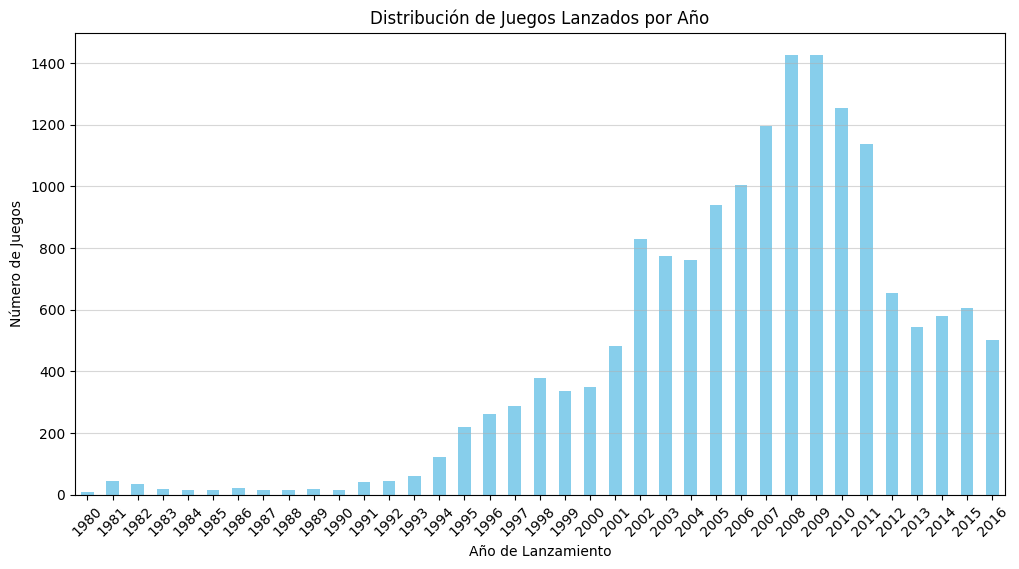

In [5]:
games_per_year = games_data.groupby('year_of_release')['name'].count()
print(games_per_year.sort_index(ascending=True))

import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
games_per_year.plot(kind='bar', color='skyblue')
plt.title('Distribución de Juegos Lanzados por Año')
plt.xlabel('Año de Lanzamiento')
plt.ylabel('Número de Juegos')
plt.grid(axis='y', alpha=0.5)
plt.xticks(rotation=45)
plt.show()

¿Son significativos los datos de cada periodo?
Los datos antes de 1994-1995 son tan pocos que son casi irrelevantes para nuestro analisis a futuro
Los datos de los ultimos años empiezan a decrecer, esto nos puede sugerir el cambio en la industrio y la diversificacion de ventas por otros medios

<div class="alert alert-block alert-success">
<b>Comentario de Revisor     </b> <a class="tocSkip"></a>

Bien, correcto. El gráfico es claro, hubo un peak a fines de los 2000 y luego ha caido a niveles similares a los de inicios del 2000.

</div>

IDENTIFICAICON DE PLATAFORMAS CON MAS VENTAS Y SEPARACION.

In [6]:
platform_sales = games_data.groupby('platform')['total_sales'].sum().sort_values(ascending=False)

print("las 10 plataformas con mas ventas")
print(platform_sales.head(10))

#Aqui estoy seprando las primeras 10 para poder analizarlas
top_platforms = platform_sales.head(10).index.tolist()

las 10 plataformas con mas ventas
platform
PS2     1233.56
X360     961.24
PS3      931.34
Wii      891.18
DS       802.78
PS       727.58
PS4      314.14
GBA      312.88
PSP      289.53
3DS      257.81
Name: total_sales, dtype: float64


<div class="alert alert-block alert-warning">
<b>Comentario de Revisor            </b> <a class="tocSkip"></a>

Bien con la data, pero un gráfico permitiría ver mejor el volumen de ventas de cada plataforma y compararlas rápidamente.

</div>

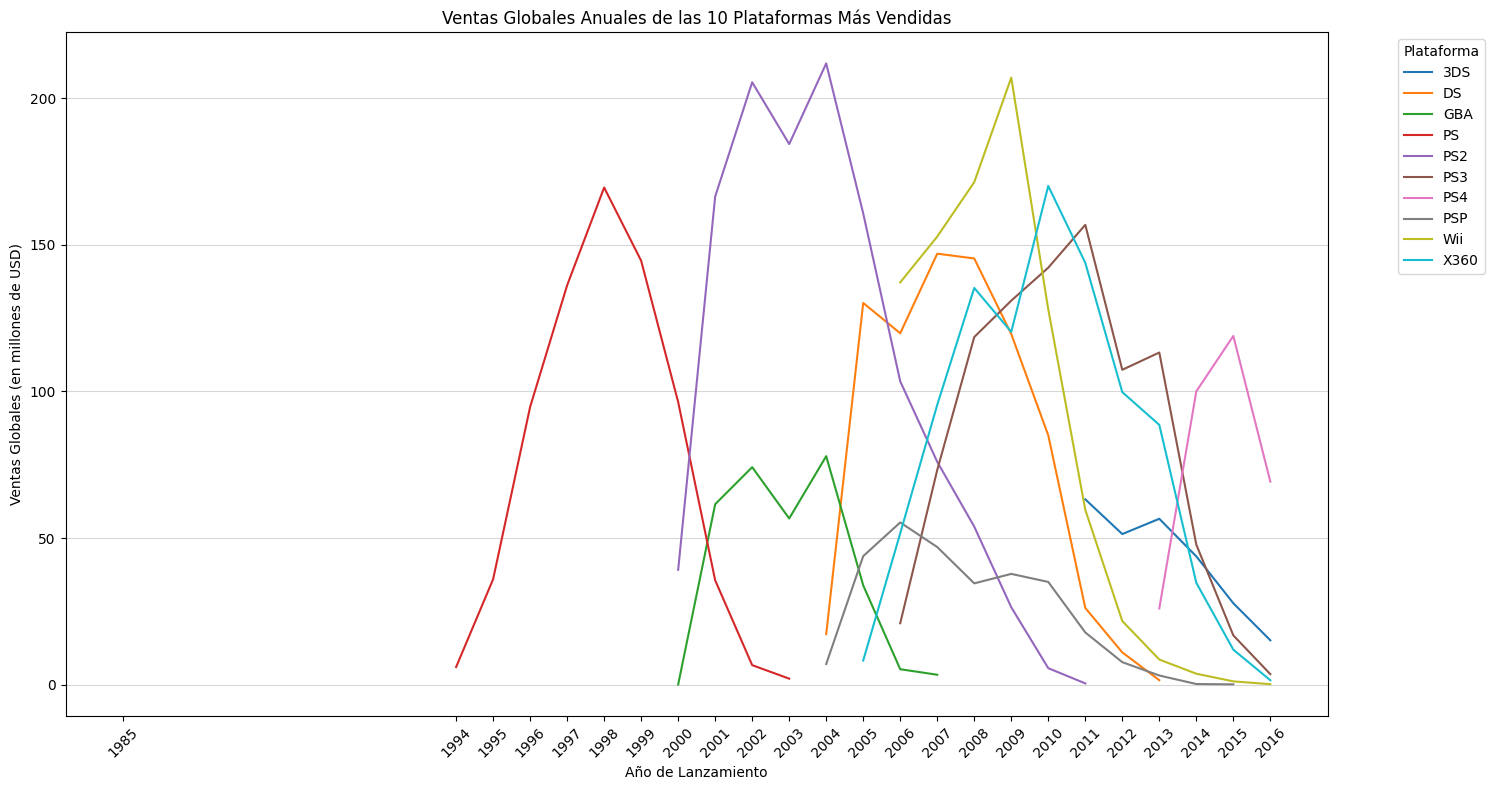

In [7]:
top_platforms_data = games_data[games_data['platform'].isin(top_platforms)]
# Agrupar por año y plataforma, y sumar las ventas totales
sales_by_year_platform = top_platforms_data.pivot_table(
    index='year_of_release',
    columns='platform',
    values='total_sales',
    aggfunc='sum'
)

# Visualizar la distribución
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 8))
sales_by_year_platform.plot(kind='line', ax=plt.gca())
plt.title('Ventas Globales Anuales de las 10 Plataformas Más Vendidas')
plt.xlabel('Año de Lanzamiento')
plt.ylabel('Ventas Globales (en millones de USD)')
plt.grid(axis='y', alpha=0.5)
plt.legend(title='Plataforma', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(sales_by_year_platform.index, rotation=45)
plt.tight_layout()
plt.show()



Generalmnete la aparicion y desaparion de nuevas plataformas es de 8 a 10 años
Cuando estan en su segundo a tercer año es cuando llegan a su punto maximo de ventas{
Plataformas pasadas como pps3,xbox360,ps2 etc actualmente tienen ventas insignificantes




<div class="alert alert-block alert-success">
<b>Comentario de Revisor            </b> <a class="tocSkip"></a>

Excelente, muy buen gráfico, permite apreciar el periodo de vida de cada consola, incluyendo su auge y luego caída.

</div>

Determinación del Período de Datos Relevante:
Como en el paso anterior determinanmos el periodo de vida y la generacion actual
usaremos como periodo relevante del 2013 en adelante.
Por lo que trabajaremos solo con datos de años posteriores a 2013

In [8]:
#aqui filtre el data frame apartir del periodo relevante
START_YEAR = 2013

relevant_data = games_data[games_data['year_of_release'] >= START_YEAR].copy()

<div class="alert alert-block alert-success">
<b>Comentario de Revisor            </b> <a class="tocSkip"></a>

Excelente, muy bien con esta decisión. Efectivamente se requiere un periodo de tiempo reciente para incluir data representativa de lo que podría ocurrir en el futuro. Esto implica que solo se pueden tener consolas que aún tienen ventas. En general, para hacer forecast en industrias muy cambiantes se recomienda tener entre 2 y 4 años.

</div>

In [9]:
¿Qué plataformas son líderes en ventas? ¿Cuáles crecen y cuáles se reducen?

Object `reducen` not found.


In [10]:
relevant_platform_sales = relevant_data.groupby('platform')['total_sales'].sum().sort_values(ascending=False)
print(relevant_platform_sales)

platform
PS4     314.14
PS3     181.43
XOne    159.32
3DS     143.25
X360    136.80
WiiU     64.63
PC       39.43
PSV      32.99
Wii      13.66
PSP       3.50
DS        1.54
Name: total_sales, dtype: float64


platform           3DS     PS3     PS4   WiiU   X360   XOne
year_of_release                                            
2013             56.57  113.25   25.99  21.65  88.58  18.96
2014             43.76   47.76  100.00  22.03  34.74  54.07
2015             27.78   16.82  118.90  16.35  11.96  60.14
2016             15.14    3.60   69.25   4.60   1.52  26.15


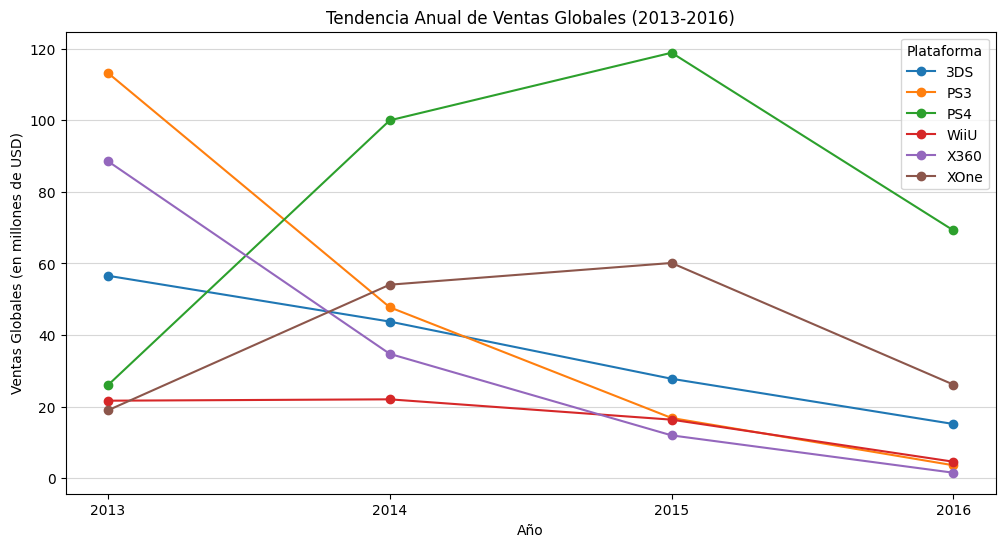

In [11]:

leader_platforms = ['PS4', 'PS3', 'XOne', '3DS', 'X360', 'WiiU']

sales_trend = relevant_data[relevant_data['platform'].isin(leader_platforms)].pivot_table(
    index='year_of_release',
    columns='platform',
    values='total_sales',
    aggfunc='sum'
)

print(sales_trend)

plt.figure(figsize=(12, 6))
sales_trend.plot(kind='line', ax=plt.gca(), marker='o')
plt.title('Tendencia Anual de Ventas Globales (2013-2016)')
plt.xlabel('Año')
plt.ylabel('Ventas Globales (en millones de USD)')
plt.grid(axis='y', alpha=0.5)
plt.legend(title='Plataforma')
plt.xticks(sales_trend.index)
plt.show()

eN EL paso anterior, cree una grafica con las plataformas lideres que ya habiamos identificado para tnener mas claro, cuales suben y cuales bajan y encontrrar una tendencia.
Como era de esperar plataformas que estaban llegando a final de su vida util empezzaron a decrecer a partir del 2013, influenciado mucho por la salida de la nueva generacion-
Siendo en este periodo relevante Xone y PS4 las plataformas mas relevantes.


<Figure size 1500x800 with 0 Axes>

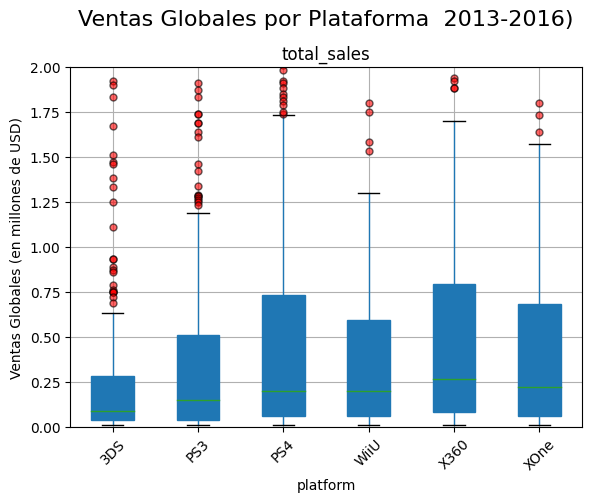

In [12]:
top_6_relevant = relevant_platform_sales.head(6).index

plt.figure(figsize=(15, 8))
relevant_data[relevant_data['platform'].isin(top_6_relevant)].boxplot(
    column='total_sales',
    by='platform',
    rot=45,
    patch_artist=True,
    flierprops=dict(marker='o', markersize=5, markerfacecolor='red', alpha=0.6)
)
plt.suptitle('Ventas Globales por Plataforma  2013-2016)', y=1.02, fontsize=16)
plt.ylabel('Ventas Globales (en millones de USD)')
plt.ylim(0, 2) 

plt.show()


<div class="alert alert-block alert-success">
<b>Comentario de Revisor            </b> <a class="tocSkip"></a>

Bien hecho, correcto el gráfico. Se puede apreciar la variabilidad de ventas de cada consola gracias a la escala limitada. Otra opción es usar una escala logarítmica.

</div>

EN  general las ventas promedio son muy parecidas en las plataformas lideres
Pero si que hay varios valores muy atipicos, que sobrepasan por mucho la cantidad de ventas promedio, que indica que hay juegos que hacen que la cantidad de ventas incrementen demasiado.
    Siendo ps4 el que muestra mas valores atipicos
Indicando que el exito de una plataforma no solo se hay que buscar que los juegos vendan mas en promedio, si no que los juegos mas atractivos y comprados esten en tu consola.
Ese podria ser un camino a seguir.
Asi que podriamos centrarnos en las tres plataformas lideres y en 3ds que tambien muestra valores atipicos-



In [13]:

leading_platforms = ['PS4', 'XOne', '3DS']
review_data = relevant_data[relevant_data['platform'].isin(leading_platforms)].copy()

print("Coeicientes de Correlación ")

for platform in leading_platforms:

    platform_subset = review_data[review_data['platform'] == platform].dropna(subset=['critic_score', 'user_score'])
    
#Correlacioasn
    corr_critic = platform_subset['total_sales'].corr(platform_subset['critic_score'])
    corr_user = platform_subset['total_sales'].corr(platform_subset['user_score'])
    
    print(f"\n{platform}:")
    print(f"  Correlación Ventas vs. Críticos: {corr_critic:.2f}")
    print(f"  Correlación Ventas vs. Usuarios: {corr_user:.2f}")

Coeicientes de Correlación 

PS4:
  Correlación Ventas vs. Críticos: 0.41
  Correlación Ventas vs. Usuarios: -0.03

XOne:
  Correlación Ventas vs. Críticos: 0.41
  Correlación Ventas vs. Usuarios: -0.09

3DS:
  Correlación Ventas vs. Críticos: 0.34
  Correlación Ventas vs. Usuarios: 0.27


lA Correlacion es postivia pero es muy baja
aunque si es mas perceptible la relacion entre las de los criticos,
tienen mas peso sus criticas y afectan mas a las ventas



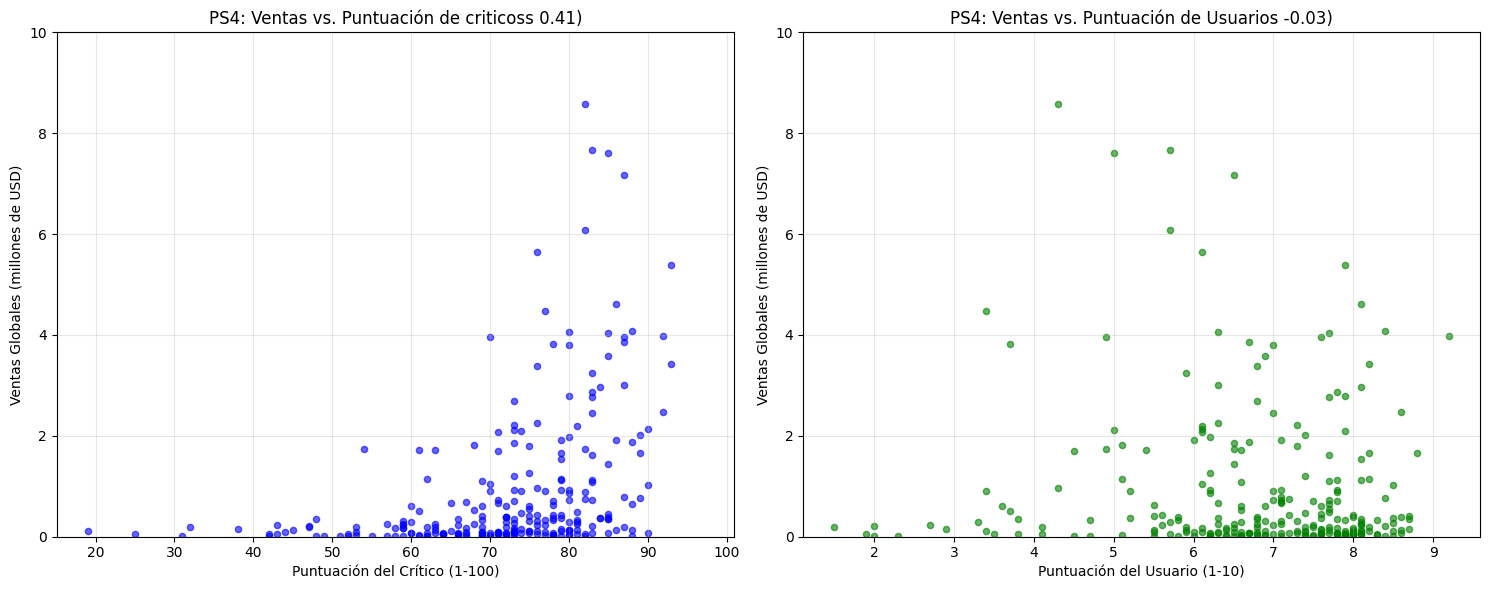

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
ps4_data = review_data[review_data['platform'] == 'PS4'].dropna(subset=['critic_score', 'user_score'])


ps4_data.plot(
    kind='scatter',
    x='critic_score',
    y='total_sales',
    ax=axes[0],
    alpha=0.6,
    color='blue'
)
axes[0].set_title(f'PS4: Ventas vs. Puntuación de criticoss {ps4_data["total_sales"].corr(ps4_data["critic_score"]):.2f})')
axes[0].set_xlabel('Puntuación del Crítico (1-100)')
axes[0].set_ylabel('Ventas Globales (millones de USD)')
axes[0].grid(axis='both', alpha=0.3)
axes[0].set_ylim(0, 10) # Limitar Y para mejor visualización
#esta es de usuarios
ps4_data.plot(
    kind='scatter',
    x='user_score',
    y='total_sales',
    ax=axes[1],
    alpha=0.6,
    color='green'
)
axes[1].set_title(f'PS4: Ventas vs. Puntuación de Usuarios {ps4_data["total_sales"].corr(ps4_data["user_score"]):.2f})')
axes[1].set_xlabel('Puntuación del Usuario (1-10)')
axes[1].set_ylabel('Ventas Globales (millones de USD)')
axes[1].grid(axis='both', alpha=0.3)
axes[1].set_ylim(0, 10) 
plt.tight_layout()


plt.show()



In [25]:
multi_pivot = relevant_data.pivot_table(
    index='name', 
    columns='platform', 
    values='total_sales', 
    aggfunc='sum'
)

top_multi_games = multi_pivot[
    (multi_pivot['PS4'] > 0) & (multi_pivot['XOne'] > 0)
].dropna(thresh=2) 

top_10_multi = top_multi_games.sort_values(by='PS4', ascending=False).head(10)

top_10_multi = top_10_multi[['PS4', 'XOne', 'PC']]

print(top_10_multi)

platform                          PS4  XOne    PC
name                                             
Call of Duty: Black Ops 3       14.63  7.39  0.26
Grand Theft Auto V              12.62  5.47  1.17
FIFA 16                          8.58  3.25  0.20
Star Wars Battlefront (2015)     7.98  3.66  0.55
Call of Duty: Advanced Warfare   7.66  5.26  0.41
FIFA 17                          7.60  2.65  0.12
Fallout 4                        7.17  4.22  1.28
FIFA 15                          6.08  2.18  0.29
Destiny                          5.64  3.37   NaN
Call of Duty: Infinite Warfare   4.47  2.42  0.13


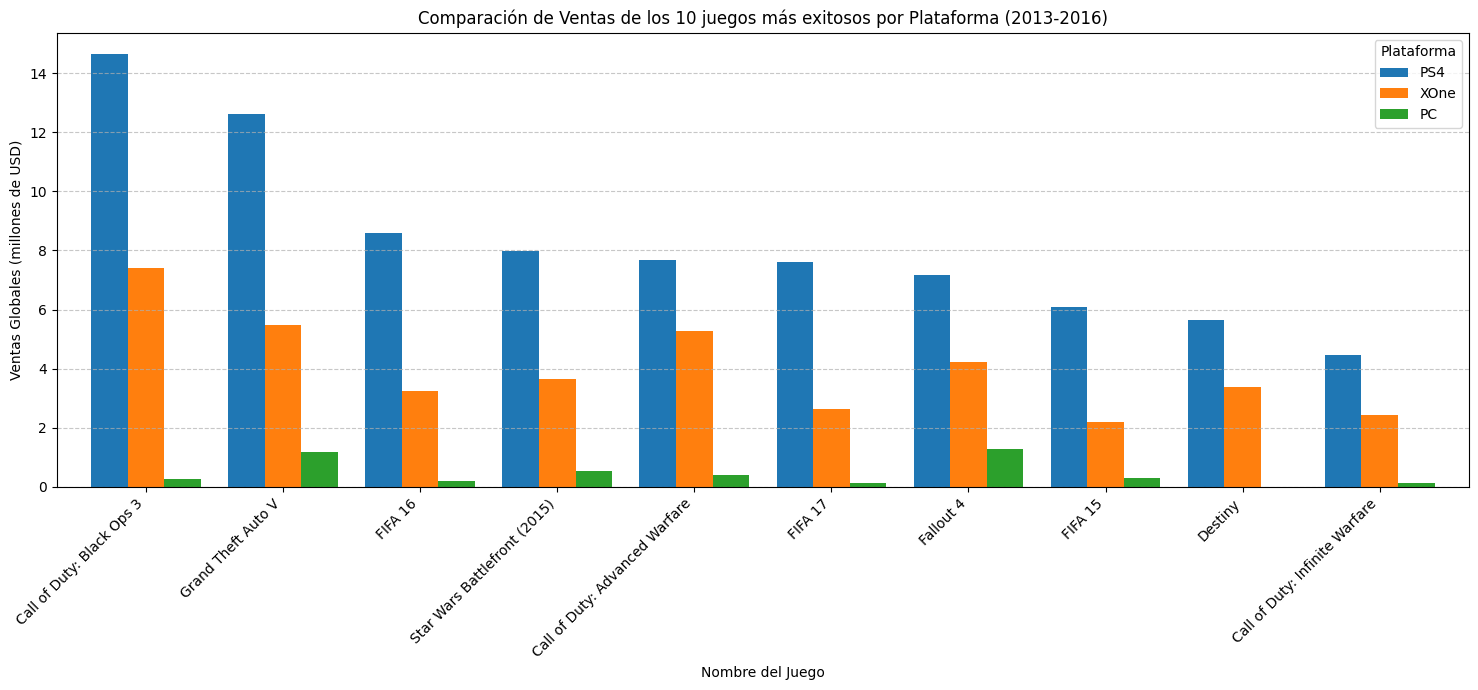

In [26]:
top_10_multi.plot(kind='bar', figsize=(15, 7), width=0.8)

plt.title('Comparación de Ventas de los 10 juegos más exitosos por Plataforma (2013-2016)')
plt.ylabel('Ventas Globales (millones de USD)')
plt.xlabel('Nombre del Juego')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title='Plataforma')
plt.tight_layout()
plt.show()


##Coomparativa de juegos multiplataforma
Hice anallizis de los 10 juegos mas vendidos que esten en las 3 plataformas
Y se pudo confirmar aun mas que los juegos de ps4 son ams vendidos.
Esto demuestra que los llamados 'hits' o juegos de calidad la ps4 tiene una base solida de consumidores mas activa, tambien confirmando que seria la principal objetivo para la campaña de 2017

<div class="alert alert-block alert-success">
<b>Comentario de Revisor            </b> <a class="tocSkip"></a>

Bien hecho con el gráfico y el cálculo del coeficiente. Permite obtener una visión general de la correlación entre ambas variables.

</div>

aQUI en las graficas si podemos verla de manera mas clara como las criticas de los criticos afectan mas que la de los usuarios
Y podemos darnos cuentas como las ventas se disparan o tienen mas correlacion con la crtica cuando superan los 70 de critica

<div class="alert alert-block alert-danger">
<b>Comentario de Revisor            </b> <a class="tocSkip"></a>

Para esta parte falta el análisis de comparación de juegos entre plataformas. Elige algunos juegos que tienen ventas altas y en varias plataformas y compara las ventas entre platataforma. Para ello, con la data anterior, puedes realizar una tabla pivote con los juegos en índice, plataformas en columnas y suma de ventas totales en valores. Luego, puedes hacer un gráfico de barras para comparar las ventas entre plataformas para cada juego.

</div>

In [16]:
genre_analysis = relevant_data.groupby('genre').agg(
    total_sales=('total_sales', 'sum'),
    game_count=('name', 'count')
).reset_index()

genre_analysis['average_sales'] = genre_analysis['total_sales'] / genre_analysis['game_count']

genre_analysis_sorted = genre_analysis.sort_values(by='total_sales', ascending=False)

print(genre_analysis_sorted)

           genre  total_sales  game_count  average_sales
0         Action       321.87         766       0.420196
8        Shooter       232.98         187       1.245882
10        Sports       150.65         214       0.703972
7   Role-Playing       145.89         292       0.499623
3           Misc        62.82         155       0.405290
4       Platform        42.63          74       0.576081
6         Racing        39.89          85       0.469294
2       Fighting        35.31          80       0.441375
1      Adventure        23.64         245       0.096490
9     Simulation        21.76          62       0.350968
11      Strategy        10.08          56       0.180000
5         Puzzle         3.17          17       0.186471


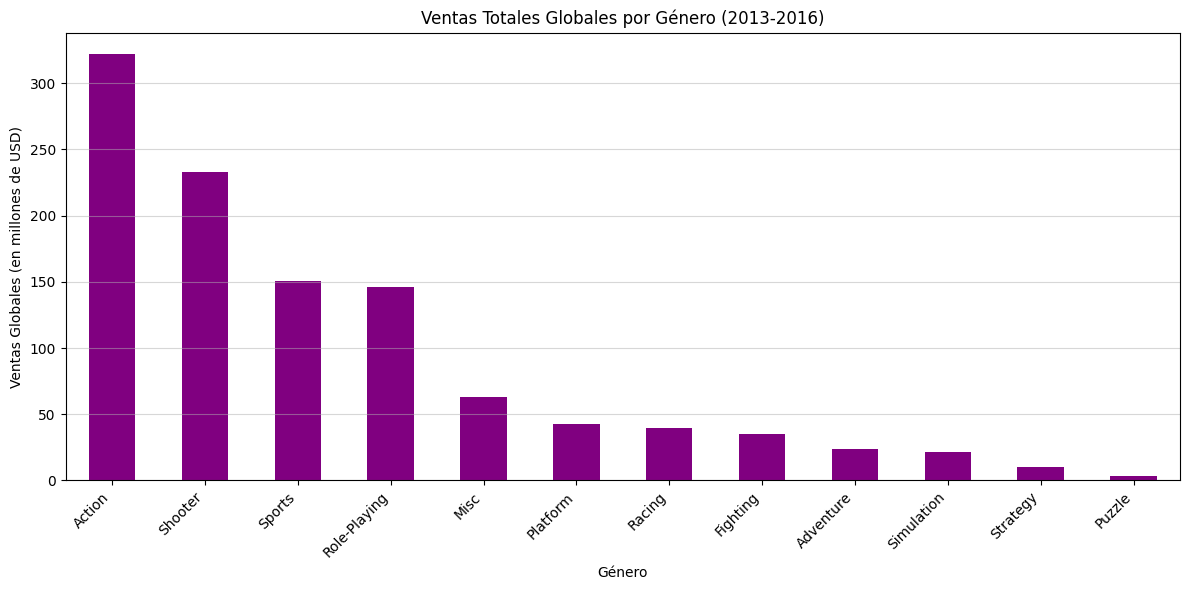

In [17]:
plt.figure(figsize=(12, 6))
genre_analysis_sorted.plot(
    kind='bar', 
    x='genre', 
    y='total_sales', 
    ax=plt.gca(), 
    color='purple',
    legend=False
)
plt.title('Ventas Totales Globales por Género (2013-2016)')
plt.xlabel('Género')
plt.ylabel('Ventas Globales (en millones de USD)')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.5)
plt.tight_layout()
plt.show()

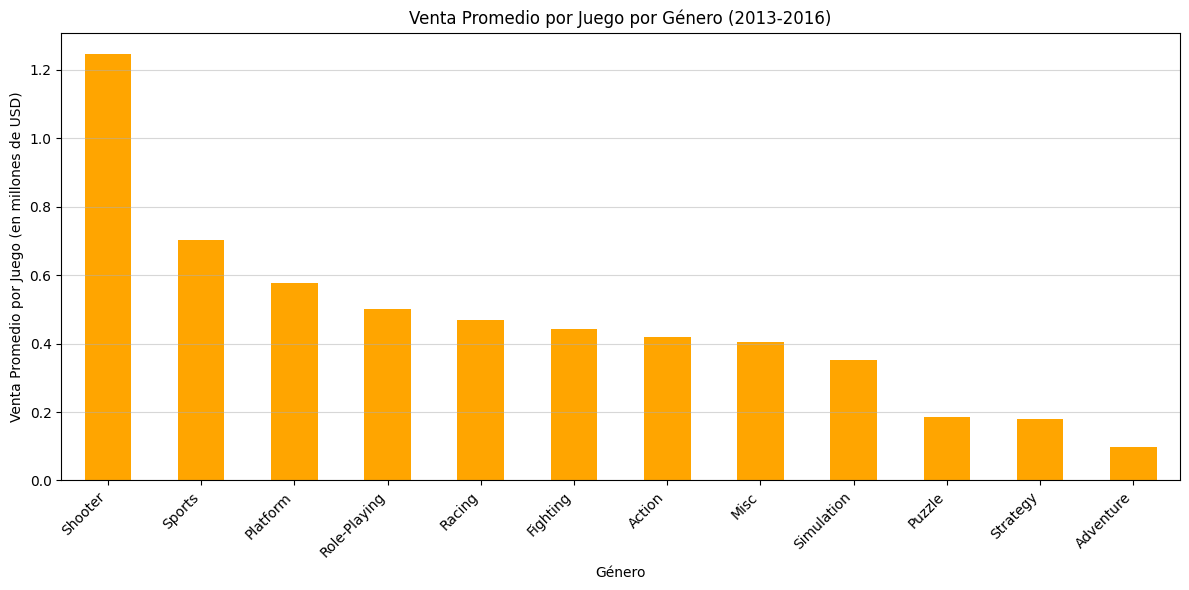

In [18]:

genre_avg_sorted = genre_analysis.sort_values(by='average_sales', ascending=False)

plt.figure(figsize=(12, 6))
genre_avg_sorted.plot(
    kind='bar', 
    x='genre', 
    y='average_sales', 
    ax=plt.gca(), 
    color='orange',
    legend=False
)
plt.title('Venta Promedio por Juego por Género (2013-2016)')
plt.xlabel('Género')
plt.ylabel('Venta Promedio por Juego (en millones de USD)')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.5)
plt.tight_layout()
plt.show()

<div class="alert alert-block alert-success">
<b>Comentario de Revisor      </b> <a class="tocSkip"></a>

Muy bien, bien hecho al mostrar ambos gráficos, vemos que hay géneros que no venden tanto en total pero debido a que tienen pocos juegos logran un alto promedio

</div>

EL genero que mas vende es el action, aunque tambien es el que mas titulos lanza.
Shooter es el que mas rentable es en ventas promedio
Deportes es igual rentable, vende mucho esto puede ser por ventas anuales como es el fifa,,nba etc
Generos con ventas bajas es puzzle, estrategia y aventura se encuentran bajos tanto en ventas como en promedio 



Crea un perfil de usuario para cada región

lAS 5 MEJORES PLATAFORMAS POR REGION

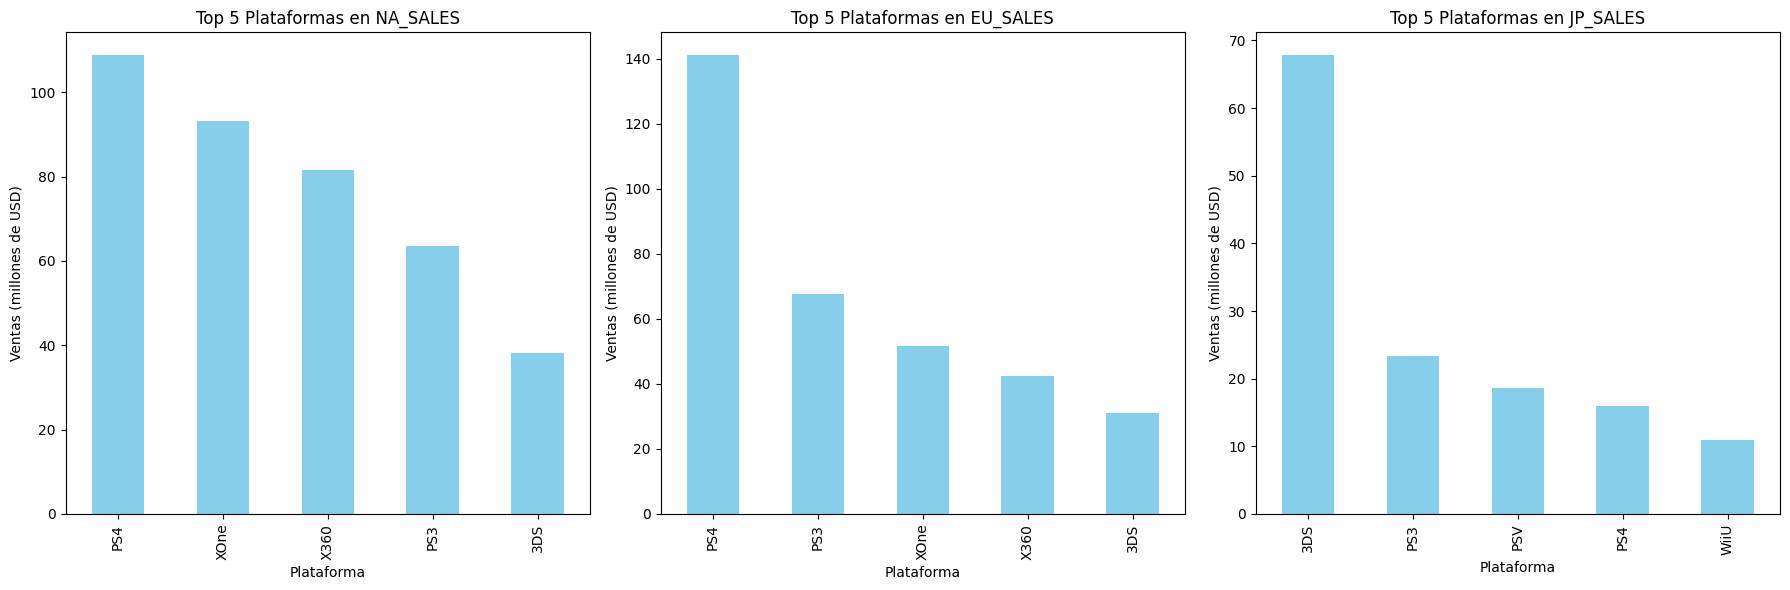

In [19]:
#Aquie} decidi investigar como hacer bien un layout para poder ver de mejor manera las diferencias por region
regions = ['na_sales', 'eu_sales', 'jp_sales']
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for i, region in enumerate(regions):
    top_platforms = relevant_data.groupby('platform')[region].sum().sort_values(ascending=False).head(5)
    top_platforms.plot(kind='bar', ax=axes[i], color='skyblue')
    axes[i].set_title(f'Top 5 Plataformas en {region.upper()}')
    axes[i].set_ylabel('Ventas (millones de USD)')
    axes[i].set_xlabel('Plataforma')

plt.tight_layout()
plt.show()

en NA Y UE son similares en cuanto a que ps4 es la mayor vendida seguida de xbox one.
Donde encontramos diferencia es en japon donde practicamente xbox es muy poco consumido.

LOS 5 MEJORES GENEROS POR REGION

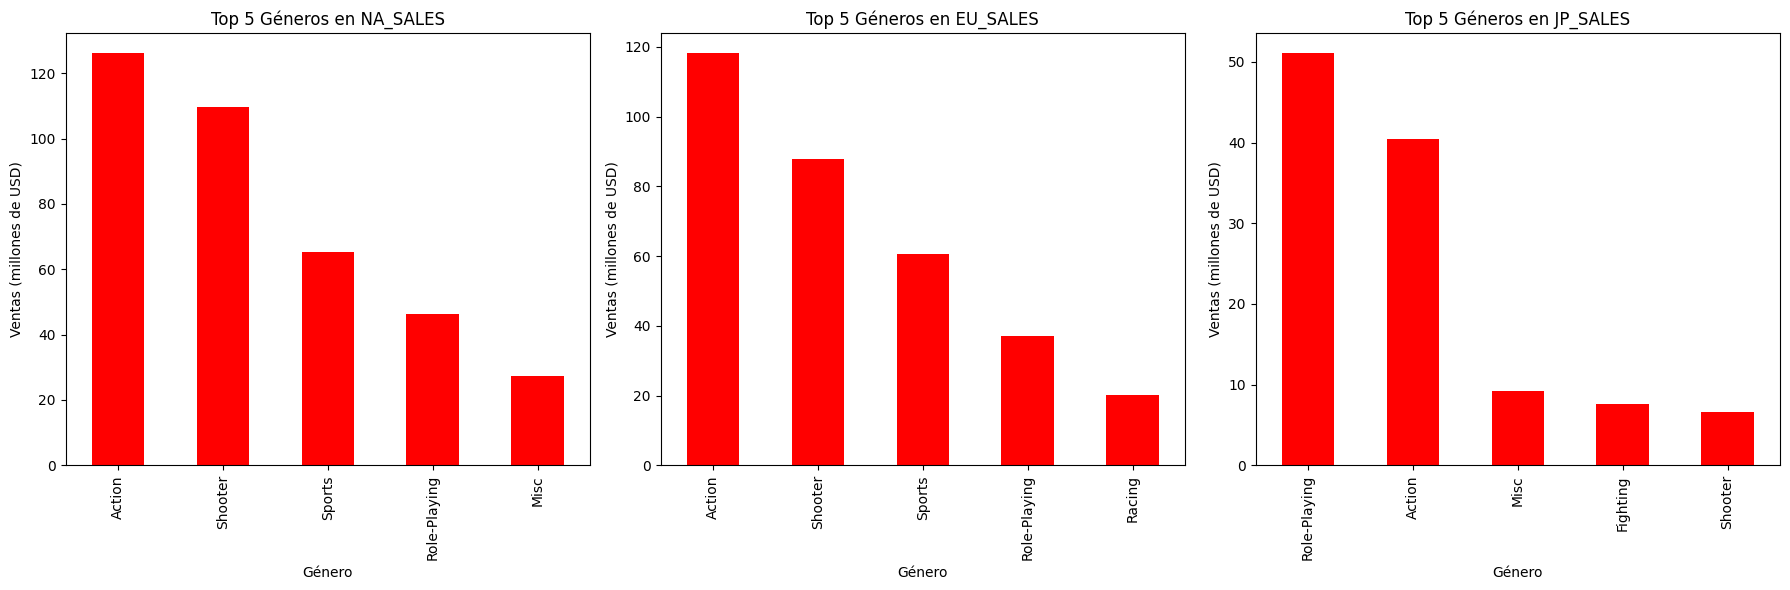

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for i, region in enumerate(regions):
    top_genres = relevant_data.groupby('genre')[region].sum().sort_values(ascending=False).head(5)
    top_genres.plot(kind='bar', ax=axes[i], color='red')
    axes[i].set_title(f'Top 5 Géneros en {region.upper()}')
    axes[i].set_ylabel('Ventas (millones de USD)')
    axes[i].set_xlabel('Género')

plt.tight_layout()
plt.show()

En cuestion de generos seguimos con NA Y UE presentan similitudes teniendo action y shooter como principales generos.
En Jp Sobresale que su genero mas consumido es el RPG

IMPACTO PORD LA CLASIFICACION ESRB POR REGION

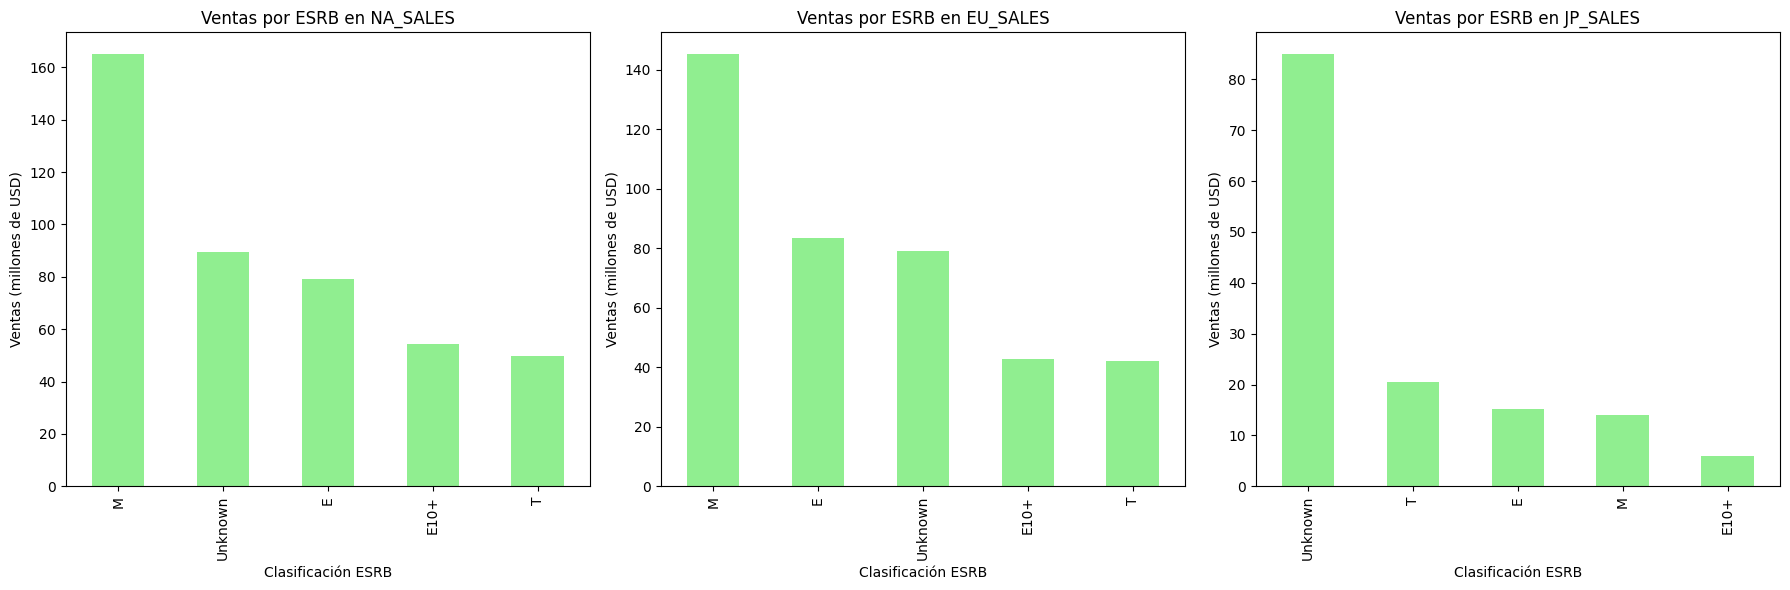

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for i, region in enumerate(regions):
    rating_sales = relevant_data.groupby('rating')[region].sum().sort_values(ascending=False)
    rating_sales.plot(kind='bar', ax=axes[i], color='lightgreen')
    axes[i].set_title(f'Ventas por ESRB en {region.upper()}')
    axes[i].set_ylabel('Ventas (millones de USD)')
    axes[i].set_xlabel('Clasificación ESRB')

plt.tight_layout()
plt.show()


En clasificaciones de edad en NA Y UE podemos ver que M o Mature es el que mas se consume esto lo podemos realcionar con que los el gnero mas vendido es el action y shooter que suelen tener juegos para adultos
Mientras que en japon tuve que investigar sobre el dataset ya que sale como unknown su clasificacion esto sucede porque en japon se utiliza otro tip de clasificaion

<div class="alert alert-block alert-success">
<b>Comentario de Revisor            </b> <a class="tocSkip"></a>

Bien hecho, muy bien con la comparación entre las regiones. Es importante revisar diferentes dimensiones entre cada uno, esto revela puntos importantes de segmentación que podrían ser beneficiosos para un modelo de predicción. Por ejemplo, observamos que Japón es muy diferente respecto a las otras regiones en varios aspectos, tal vez esto justifique diferentes modelos o reglas para esta región.
    
</div>

HIPOTESIS : — Las calificaciones promedio de los usuarios para las plataformas Xbox One y PC son las mismas.


In [22]:
#Aqui preparo el alpha, y limmpio de nuevo el data
from scipy import stats as st


data_ratings = relevant_data.dropna(subset=['user_score'])
alpha = 0.05 

xone_ratings = data_ratings[data_ratings['platform'] == 'XOne']['user_score']
pc_ratings = data_ratings[data_ratings['platform'] == 'PC']['user_score']

results_1 = st.ttest_ind(xone_ratings, pc_ratings, equal_var=False)

print(f"Prueba 1 (Plataformas) - Valor p: {results_1.pvalue}")

if results_1.pvalue < alpha:
    print("Rechazamos la hipótesis nula: Las calificaciones promedio son diferentes.")
else:
    print("No podemos rechazar la hipótesis nula: No hay evidencia suficiente para decir que son diferentes.")

Prueba 1 (Plataformas) - Valor p: 0.14759594013430463
No podemos rechazar la hipótesis nula: No hay evidencia suficiente para decir que son diferentes.


Generalmente en 2013-201 el valor p es mayor a 0.05, lo que indica que no hay una diferencia estadísticamente significativa entre las calificaciones de los usuarios de Xbox One y PC.


Hipotesis: — Las calificaciones promedio de los usuarios para los géneros de Acción y Deportes son diferentes.
H₀ (Hipótesis Nula): Las calificaciones promedio de los usuarios para los géneros de Acción y Deportes son iguales.

H₁ (Hipótesis Alternativa): Las calificaciones promedio de los usuarios para los géneros de Acción y Deportes son diferentes.

In [23]:
action_ratings = data_ratings[data_ratings['genre'] == 'Action']['user_score']
sports_ratings = data_ratings[data_ratings['genre'] == 'Sports']['user_score']

# Ejecutar la prueba t
results_2 = st.ttest_ind(action_ratings, sports_ratings, equal_var=False)

print(f"Prueba 2 (Géneros) - Valor p: {results_2.pvalue}")

if results_2.pvalue < alpha:
    print("Rechazamos la hipótesis nula: Las calificaciones promedio para Acción y Deportes son diferentes.")
else:
    print("No podemos rechazar la hipótesis nula: No hay evidencia de diferencia.")

Prueba 2 (Géneros) - Valor p: 1.4460039700704315e-20
Rechazamos la hipótesis nula: Las calificaciones promedio para Acción y Deportes son diferentes.


El valor de p es muy pqueño menor a 0-05 lo que inidca qie podemos rechazar la hipotesis nula, por lo tanto las calificaciones de los usuarios para los juegos de accion y deportes son significativamente diferentes


Realizmos las pruebas de hipotesis para determinar si los datos son signifcativamente diferentes y relevantes en el data set o si no son cuestion de azar
por eso mis hipotesis fueron una nula y una alternativa
h0: Las calificaciones promedio de los usuarios para las plataformas Xbox One y PC son iguales.
h1: Las calificaciones promedio de los usuarios para las plataformas Xbox One y PC son diferentes.
y ara la hipotesis dos lo planee de esta forma
H0 Las calificaciones promedio de los usuarios para los géneros de Acción y Deportes son iguales.
H1: Las calificaciones promedio de los usuarios para los géneros de Acción y Deportes son diferentes.

Mi criterio para probar la hipotesis y porque:
USe la prueba t de student para casos independientes
Utilice las medias o promedios de variables que en este caso fueron las califiaciones por usuario frente a otros grupos
y casos independientes por ejemplo pc no influye en xbox, son poblaciones distintas.

Para rechazar o no estableci el nivel de significacion o el alpha en 5% ya que es lo que hemos venido usando en ejercicios anteriores y ademas en un margen muy contundente para poder rechazar o no una hipotesis
Y tamien utilice el valor de p

<div class="alert alert-block alert-success">
<b>Comentario de Revisor            </b> <a class="tocSkip"></a>

Bien hecho con los tests, fueron realizados de forma correcta. 

Es importante mencionar que el t-test asume que las dos muestras tienen varianzas iguales Para verificar esa igualdad de varianzas podemos usar el **test de Levene**. Este nos dice si la variabilidad entre los grupos es *estadísticamente diferente*. En futuros notebooks podrías utilizar este test para decidir sobre la igualdad de varianzas. En corto, el flujo sería así

1. Usamos `levene()` para verificar si las varianzas son iguales.
2. Dependiendo del resultado, usamos `ttest_ind()` con el argumento `equal_var`:
   - `equal_var=True` si Levene dice que las varianzas son iguales (p > 0.05).
   - `equal_var=False` si Levene dice que las varianzas son diferentes (p < 0.05).

</div>

COBCLUSION GENERAL:

Para esta conclusion general y organizarme lo hare a modo de pequeño resumen para ser un poco mas claro.

OBJETIVO DEL PROYECTO.
Se analizo un dataset de videojuegos, para poder determinar o ver patrones en ventas, para poder trazar o darnos una idea de canpaña publicitaria para el año 2017-

Al analizar y despues limpiar los datos, nos dimos cuenta que el periodo relevante de los datos es del 2013 en adelante, esto n os ayudara a tener un enfoque actual sin que datos que no sean relevantes sesguen la informacion-

Los hallazgos claves para empezar fue que las plataformas lideres y mas influyentes para 2017 son tanto ps4 como xbox ones, por lo que se debe priorizar en esas dos.

La vida util de ps3 y x360 esta llegando a su final, una razon mas para no enfocarse en ellas.

Otro hallazgo intersenate es que mucha de la rentabilidad se basa en los valores atipicos de ventas en videojeugos o lo que son 'hits' esos juegos hacen que suba la media.

En cuanto a los generos.
Accion es el mas vendido, pero en realidad los shooters son los mass rentables porque son los que generan mas en promedio  por juego lanzado.
Los puzzles y estrategia son los que menos generan

En cuanto a las califiaciones, las criticas de profesionales suelen influir de forma muy sutil, pero las criticas de usuarios su relevancia es casi  nula.

En cuanto a los perfiles regionales los en JP su plataforma mas vendida es 3ds por lo que prefieren consolas mas portatiles, su genero preferido es rpg y es descobnocida la esrb ya que en japon usan otro fromato.
En NA Y UE son similares, siendo shooter y accion su genero mas vendido, ps4 como plataforma mas vendida seguida por xone y su esbr es M o mature

Algunas recomendaciones para la campaña 2017 seria en Na Y Ue centrarse en juegos de shooter y accion para adultos y en ps4
En jp es recomendable intentar centrarse en juegos rpg o familiares para consolas portatiles.

Y centrarse publicitariamente en juegos que pasen de 80 de calificacion por parte de crit


<div class="alert alert-block alert-success">
<b>Comentario de Revisor            </b> <a class="tocSkip"></a>

Muy bien con estas conclusiones. Entre los puntos más importantes para el pronóstico de 2017 están las plataformas que serán relevantes, la segmentación de géneros por importancia de ventas y la caracterización de cada región. Para realizar una predicción del siguiente año se podría considerar cada segmento por separado para ajustar diferentes modelos.
    
Podrías mejorar tus conclusiones incluyendo algunos valores de las métricas más importantes, así las afirmaciones realizadas estarían mejor apoyadas en hechos.
    
</div>